# [Domanda] Lo Stato italiano e' strutturalmente in deficit?

Notebook di analisi in risposta alla [Discussion #9](https://github.com/dataciviclab/openbdap-saldi-storico-stato/discussions/9) del repository `openbdap-saldi-storico-stato`.

## Domanda
Lo Stato italiano presenta un deficit strutturale nel tempo, oppure i saldi negativi sono concentrati in fasi eccezionali?

## Ipotesi iniziali
- L'Italia presenta deficit strutturale da decenni.
- Le crisi amplificano ma non creano il problema.
- La fase pre-2008 potrebbe mostrare miglioramenti parziali.

## Metriche considerate
- Indebitamento Netto
- Saldo Netto da Finanziare
- Ricorso al Mercato
- Avanzo Primario
- Spese per interessi
- Quota di anni con saldo negativo
- Medie per periodo

## Nota metodologica
In questo notebook usiamo i dati di consuntivo per leggere la serie storica dei principali saldi dello Stato. Trattiamo `strutturale` in senso operativo: un saldo e' strutturalmente negativo se resta sotto zero nella maggior parte degli anni osservati, e non solo durante shock eccezionali.

L'Indebitamento Netto e' l'indicatore principale della presenza di deficit nel tempo. Il Saldo Netto da Finanziare e il Ricorso al Mercato vengono letti come misure correlate, ma non equivalenti: aiutano a contestualizzare il fabbisogno e il ricorso al finanziamento.

I valori sono letti in euro correnti e nei grafici vengono espressi in miliardi di euro.


In [ ]:
from pathlib import Path
import os

def maybe_mount_drive() -> None:
    try:
        from google.colab import drive
        drive.mount('/content/drive')
    except Exception:
        pass

maybe_mount_drive()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')


In [ ]:
# Path del clean: prova prima Drive/Colab, poi un root esplicito via env, poi il repo locale
def discover_root() -> Path:
    env_root = os.getenv('DCL_ROOT')
    if env_root:
        return Path(env_root)
    drive_root = Path('/content/drive/MyDrive/DataCivicLab')
    if drive_root.exists():
        return drive_root
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / 'data').exists() and (candidate / 'notebooks').exists():
            return candidate
    return cwd

def latest_run_dir(root: Path) -> Path:
    run_dirs = sorted([p for p in root.iterdir() if p.is_dir()], key=lambda p: p.name)
    if not run_dirs:
        raise FileNotFoundError(f'No run dirs in: {root}')
    return run_dirs[-1]

ROOT = discover_root()
CLEAN_ROOT = ROOT / 'data' / 'clean' / 'openbdap_rendiconto_saldi_storico'
RUN_DIR = latest_run_dir(CLEAN_ROOT)
FILE_PATH = RUN_DIR / 'saldi_storico.parquet'

if FILE_PATH.suffix == '.parquet':
    df = pd.read_parquet(FILE_PATH)
else:
    df = pd.read_csv(FILE_PATH)

print(f'Using clean file: {FILE_PATH}')
df.head()


In [ ]:
print(df.shape)
print(df.columns.tolist())
print(f"Anni presenti nel file: {df['esercizio_finanziario'].min()} - {df['esercizio_finanziario'].max()}")
print(f"Numero di annualita': {df['esercizio_finanziario'].nunique()}")


(22, 22)
['esercizio_finanziario', 'risparmio_pubblico', 'saldo_netto_da_finanziare', 'indebitamento_netto', 'ricorso_al_mercato', 'avanzo_primario', 'spese_correnti', 'spese_per_interessi', 'spese_in_conto_capitale', 'spese_acquisizione_attivita_finanziarie', 'spese_per_rimborso_prestiti', 'spese_complessive', 'spese_finali', 'spese_finali_netto_att_fin', 'entrate_tributarie', 'entrate_extra_tributarie', 'entrate_alienazioni_patrimoniali_e_riscossioni', 'riscossione_crediti', 'entrate_accensione_prestiti', 'entrate_finali', 'entrate_fin_netto_riscossione_crediti', 'entrate_correnti']
Anni presenti nel file: 2003 - 2024
Numero di annualita': 22


## 1. Preparazione del dataset analitico

Selezioniamo i saldi essenziali per la domanda della discussion e aggiungiamo la spesa per interessi, utile per leggere il rapporto tra saldo complessivo e avanzo primario.


In [ ]:
colonne_utili = [
    'esercizio_finanziario',
    'saldo_netto_da_finanziare',
    'indebitamento_netto',
    'ricorso_al_mercato',
    'avanzo_primario',
    'spese_per_interessi',
]

tab = df[colonne_utili].copy()
tab = tab.rename(columns={'esercizio_finanziario': 'anno'})

for col in tab.columns:
    tab[col] = pd.to_numeric(tab[col], errors='coerce')

tab = tab.dropna(subset=['anno']).sort_values('anno')
tab['anno'] = tab['anno'].astype(int)

assert tab['anno'].is_unique, 'Ogni anno dovrebbe comparire una sola volta nel clean finale.'

tab.head()


,anno,saldo_netto_da_finanziare,indebitamento_netto,ricorso_al_mercato,avanzo_primario,spese_per_interessi
0,2003,"-76,608,438,560.85","-70,589,525,371.85","-333,428,879,750.18","-469,519,795.74","76,138,918,765.11"
1,2004,"-63,777,783,304.76","-57,927,611,571.76","-298,880,446,856.76","11,342,166,924.46","75,119,950,229.22"
2,2005,"-58,445,411,507.42","-55,169,109,483.42","-259,929,492,773.42","17,967,721,312.10","76,413,132,819.52"
3,2006,"-45,004,367,358.10","-45,602,974,733.10","-234,128,614,666.10","30,689,365,339.90","75,693,732,698.00"
4,2007,"-32,446,030,884.00","-32,180,004,416.00","-223,639,678,240.00","44,089,973,785.87","76,536,004,669.87"


In [ ]:
display(tab.isna().sum())
print(f"Periodo coperto dall'analisi: {tab['anno'].min()} - {tab['anno'].max()}")

anni_attesi = set(range(tab['anno'].min(), tab['anno'].max() + 1))
anni_presenti = set(tab['anno'].tolist())
anni_mancanti = sorted(anni_attesi - anni_presenti)
print(f"Annualita' mancanti nel range osservato: {anni_mancanti if anni_mancanti else 'nessuna'}")


,0
anno,0
saldo_netto_da_finanziare,0
indebitamento_netto,0
ricorso_al_mercato,0
avanzo_primario,0
spese_per_interessi,0


Periodo coperto dall'analisi: 2003 - 2024
Annualita' mancanti nel range osservato: nessuna


## 2. Serie storica dei principali saldi

Qui mettiamo a confronto i quattro indicatori principali. L'Indebitamento Netto resta la metrica guida per la domanda, mentre gli altri saldi aiutano a capire come si distribuisce il disequilibrio.


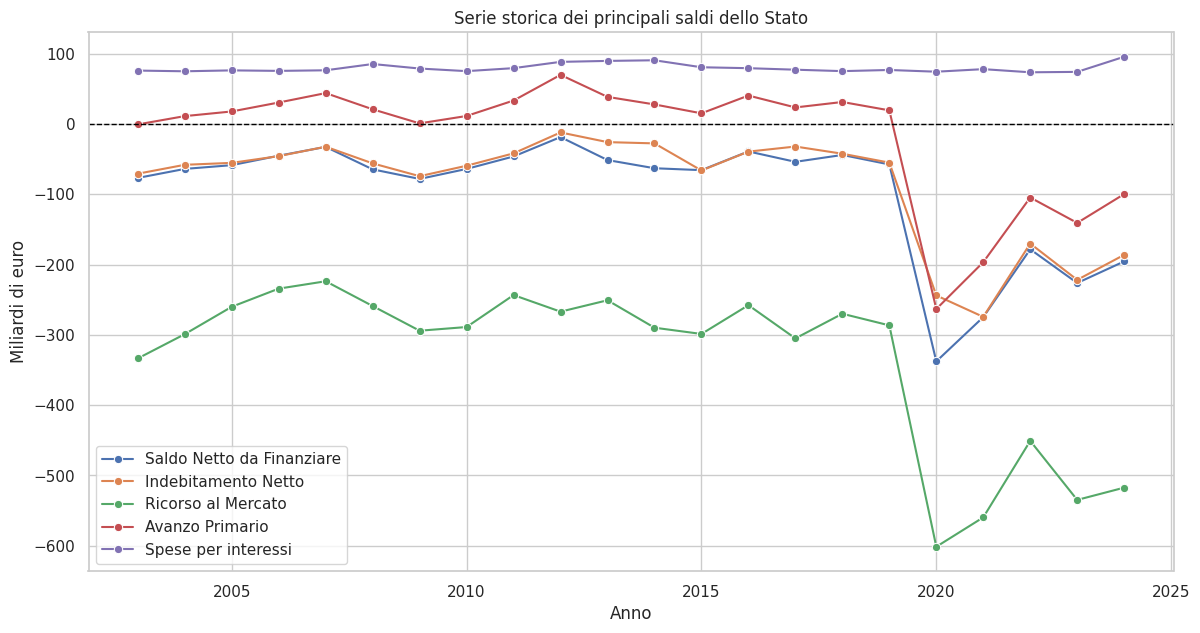

In [ ]:
plot_df = tab.melt(id_vars='anno', var_name='saldo', value_name='valore')

etichette = {
    'saldo_netto_da_finanziare': 'Saldo Netto da Finanziare',
    'indebitamento_netto': 'Indebitamento Netto',
    'ricorso_al_mercato': 'Ricorso al Mercato',
    'avanzo_primario': 'Avanzo Primario',
    'spese_per_interessi': 'Spese per interessi',
}

plot_df['saldo_label'] = plot_df['saldo'].map(etichette)
plot_df['valore_mld'] = plot_df['valore'] / 1e9

plt.figure(figsize=(14, 7))
sns.lineplot(data=plot_df, x='anno', y='valore_mld', hue='saldo_label', marker='o')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Serie storica dei principali saldi dello Stato')
plt.xlabel('Anno')
plt.ylabel('Miliardi di euro')
plt.legend(title='')
plt.show()


## 3. Quota di anni con saldo negativo

Misuriamo quanto spesso ciascun saldo scende sotto zero. Questo passaggio e' centrale per evitare conclusioni impressionistiche.


,saldo_label,anni_totali,anni_negativi,media_mld,quota_anni_negativi
1,Indebitamento Netto,22,22,-85.79,1.00
3,Saldo Netto da Finanziare,22,22,-96.94,1.00
2,Ricorso al Mercato,22,22,-332.88,1.00
0,Avanzo Primario,22,6,-16.65,0.27
4,Spese per interessi,22,0,79.78,0.00


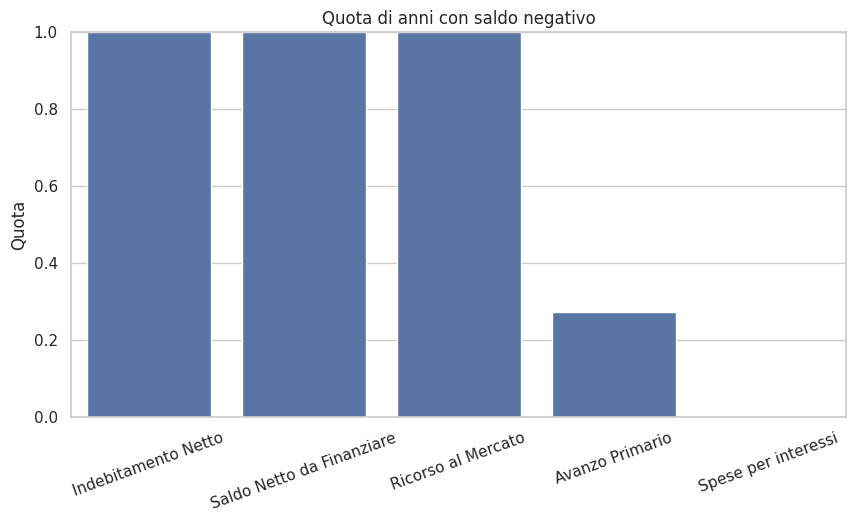

In [ ]:
neg_summary = (
    plot_df.assign(negativo=lambda d: d['valore'] < 0)
    .groupby('saldo_label', as_index=False)
    .agg(
        anni_totali=('anno', 'count'),
        anni_negativi=('negativo', 'sum'),
        media_mld=('valore_mld', 'mean'),
    )
)

neg_summary['quota_anni_negativi'] = neg_summary['anni_negativi'] / neg_summary['anni_totali']
neg_summary = neg_summary.sort_values('quota_anni_negativi', ascending=False)
display(neg_summary)

plt.figure(figsize=(10, 5))
sns.barplot(data=neg_summary, x='saldo_label', y='quota_anni_negativi')
plt.ylim(0, 1)
plt.title('Quota di anni con saldo negativo')
plt.xlabel('')
plt.ylabel('Quota')
plt.xticks(rotation=20)
plt.show()


## 4. Medie per periodo storico

Questa periodizzazione serve a distinguere tendenza di lungo periodo e shock. Se i saldi restano negativi anche fuori dai momenti di crisi, la lettura strutturale diventa piu' solida.


,periodo,saldo_label,media_periodo_mld
0,2003-2007,Avanzo Primario,20.72
1,2003-2007,Indebitamento Netto,-52.29
2,2003-2007,Ricorso al Mercato,-270.00
3,2003-2007,Saldo Netto da Finanziare,-55.26
4,2003-2007,Spese per interessi,75.98
5,2008-2012,Avanzo Primario,27.43
6,2008-2012,Indebitamento Netto,-48.57
7,2008-2012,Ricorso al Mercato,-270.36
8,2008-2012,Saldo Netto da Finanziare,-54.16
9,2008-2012,Spese per interessi,81.59


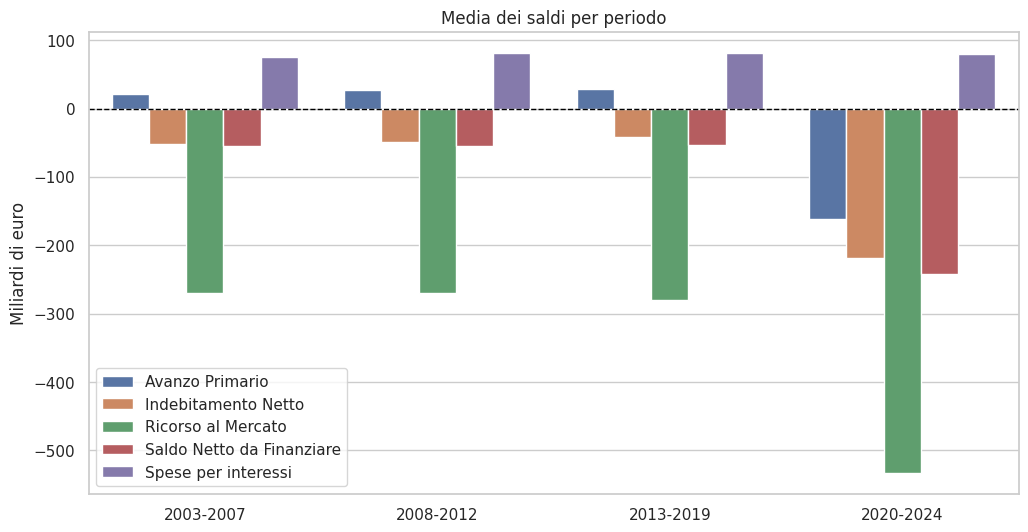

In [ ]:
def assegna_periodo(anno: int) -> str:
    if 2003 <= anno <= 2007:
        return '2003-2007'
    if 2008 <= anno <= 2012:
        return '2008-2012'
    if 2013 <= anno <= 2019:
        return '2013-2019'
    if 2020 <= anno <= 2024:
        return '2020-2024'
    return 'Altro'

plot_df['periodo'] = plot_df['anno'].map(assegna_periodo)

periodi = (
    plot_df.groupby(['periodo', 'saldo_label'], as_index=False)['valore_mld']
    .mean()
    .rename(columns={'valore_mld': 'media_periodo_mld'})
)

display(periodi)

plt.figure(figsize=(12, 6))
sns.barplot(data=periodi, x='periodo', y='media_periodo_mld', hue='saldo_label')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Media dei saldi per periodo')
plt.xlabel('')
plt.ylabel('Miliardi di euro')
plt.legend(title='')
plt.show()


## 5. Avanzo primario, interessi e indebitamento netto

Questo passaggio evita una lettura troppo semplice del deficit. Se l'avanzo primario e' spesso positivo ma l'Indebitamento Netto resta negativo, una parte rilevante del disequilibrio passa dal peso degli interessi.


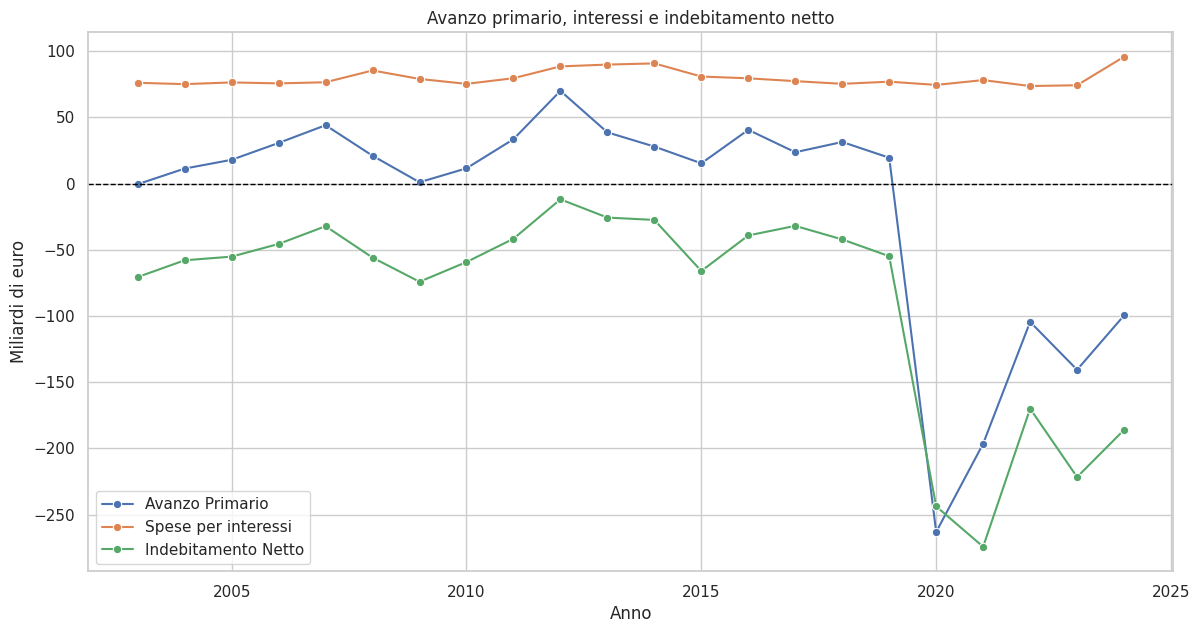

Anni con avanzo primario positivo: 16 su 22
Quota anni con avanzo primario positivo: 72.7%


In [ ]:
focus = tab[['anno', 'avanzo_primario', 'spese_per_interessi', 'indebitamento_netto']].copy()
focus['avanzo_primario_mld'] = focus['avanzo_primario'] / 1e9
focus['spese_per_interessi_mld'] = focus['spese_per_interessi'] / 1e9
focus['indebitamento_netto_mld'] = focus['indebitamento_netto'] / 1e9

focus_long = focus.melt(
    id_vars='anno',
    value_vars=['avanzo_primario_mld', 'spese_per_interessi_mld', 'indebitamento_netto_mld'],
    var_name='metrica',
    value_name='valore_mld',
)

etichette_focus = {
    'avanzo_primario_mld': 'Avanzo Primario',
    'spese_per_interessi_mld': 'Spese per interessi',
    'indebitamento_netto_mld': 'Indebitamento Netto',
}
focus_long['metrica_label'] = focus_long['metrica'].map(etichette_focus)

plt.figure(figsize=(14, 7))
sns.lineplot(data=focus_long, x='anno', y='valore_mld', hue='metrica_label', marker='o')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Avanzo primario, interessi e indebitamento netto')
plt.xlabel('Anno')
plt.ylabel('Miliardi di euro')
plt.legend(title='')
plt.show()

anni_avanzo_positivo = int((focus['avanzo_primario'] > 0).sum())
quota_avanzo_positivo = (focus['avanzo_primario'] > 0).mean()
print(f"Anni con avanzo primario positivo: {anni_avanzo_positivo} su {len(focus)}")
print(f"Quota anni con avanzo primario positivo: {quota_avanzo_positivo:.1%}")


## 6. Focus sull'Indebitamento Netto

Qui isoliamo l'indicatore principale della discussion e sintetizziamo quanto spesso e quanto intensamente resta sotto zero.


Anni osservati: 22
Anni con indebitamento netto negativo: 22
Quota anni negativi: 100.0%
Media periodo: -85,790,945,192.50


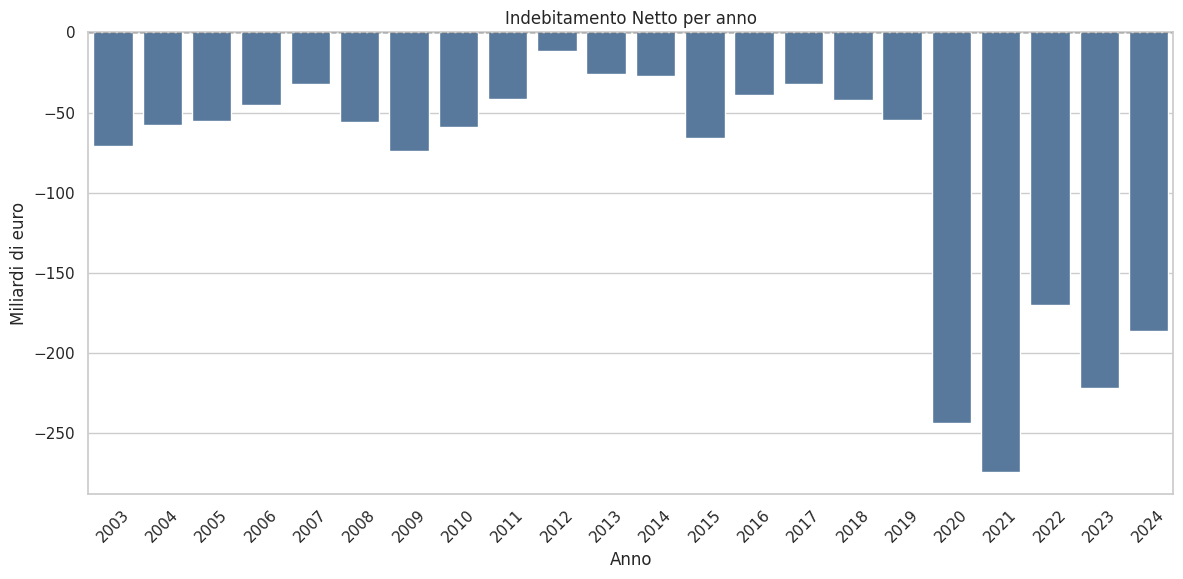

In [ ]:
indeb = tab[['anno', 'indebitamento_netto']].dropna().copy()
indeb['negativo'] = indeb['indebitamento_netto'] < 0
indeb['indebitamento_netto_mld'] = indeb['indebitamento_netto'] / 1e9

anni_tot = len(indeb)
anni_neg = int(indeb['negativo'].sum())
quota_neg = anni_neg / anni_tot if anni_tot else float('nan')

print(f"Anni osservati: {anni_tot}")
print(f"Anni con indebitamento netto negativo: {anni_neg}")
print(f"Quota anni negativi: {quota_neg:.1%}")
print(f"Media periodo: {indeb['indebitamento_netto'].mean():,.2f}")

plt.figure(figsize=(14, 6))
sns.barplot(data=indeb, x='anno', y='indebitamento_netto_mld', color='#4C78A8')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Indebitamento Netto per anno')
plt.xlabel('Anno')
plt.ylabel('Miliardi di euro')
plt.xticks(rotation=45)
plt.show()


## 7. Evidenze sintetiche


In [ ]:
anno_migliore = int(indeb.loc[indeb['indebitamento_netto'].idxmax(), 'anno'])
anno_peggiore = int(indeb.loc[indeb['indebitamento_netto'].idxmin(), 'anno'])

evidenze = pd.DataFrame({
    'metrica': [
        'Periodo coperto',
        'Anni osservati',
        'Anni con Indebitamento Netto negativo',
        'Quota anni con Indebitamento Netto negativo',
        'Quota anni con Avanzo Primario positivo',
        'Media Indebitamento Netto',
        'Anno migliore',
        'Anno peggiore',
    ],
    'valore': [
        f"{tab['anno'].min()}-{tab['anno'].max()}",
        anni_tot,
        anni_neg,
        f"{quota_neg:.1%}",
        f"{quota_avanzo_positivo:.1%}",
        round(indeb['indebitamento_netto'].mean(), 2),
        anno_migliore,
        anno_peggiore,
    ]
})

evidenze


,metrica,valore
0,Periodo coperto,2003-2024
1,Anni osservati,22
2,Anni con Indebitamento Netto negativo,22
3,Quota anni con Indebitamento Netto negativo,100.0%
4,Quota anni con Avanzo Primario positivo,72.7%
5,Media Indebitamento Netto,"-85,790,945,192.50"
6,Anno migliore,2012
7,Anno peggiore,2021


## 8. Risposta alla domanda

### Cosa emerge
- L'Indebitamento Netto e' l'indicatore piu' diretto per valutare la presenza di deficit nel tempo.
- Nel file analizzato il saldo e' negativo in tutti gli anni osservati, dal 2003 al 2024.
- Questo dato rende molto forte l'ipotesi di un deficit strutturale: le crisi peggiorano il quadro, ma non coincidono con l'origine del segno negativo.

### Come leggere gli altri saldi
- Il Saldo Netto da Finanziare aiuta a valutare il fabbisogno del bilancio statale, ma non sostituisce l'Indebitamento Netto come misura del deficit.
- Il Ricorso al Mercato misura la necessita' di finanziamento tramite mercato e segnala quanto il bilancio richieda raccolta di risorse.
- L'Avanzo Primario e' utile perche' mostra che in varie fasi il bilancio, al netto degli interessi, e' piu' vicino all'equilibrio del saldo complessivo.

### Conclusione
Sulla base della serie storica di consuntivo 2003-2024, lo Stato italiano mostra un deficit strutturale nel periodo osservato. L'Indebitamento Netto non torna mai positivo, mentre le crisi del 2008-2012 e del 2020-2021 aggravano una traiettoria gia' negativa. Il confronto con l'Avanzo Primario suggerisce inoltre che una parte importante del disavanzo complessivo sia legata al peso degli interessi, non solo alla dinamica della spesa primaria.
